In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
"""
loss_list = []
isi_list = []
for run in range(1,7):
    datapath = f"/data/users4/xli/MISA/MISA-pytorch/runs/OHBM25/run{run}/res_sim-siva_dataset100_source12_sample32768_seed7_wpca.p"
    res = pickle.load(open(datapath, "rb"))
    print(f"run {run}; learning rate: {res['lr']}; batch size: {res['batch_size']}; epochs: {res['epochs']}")
    loss_list.append(res['loss'][0])
    isi_list.append(res['MISI'][0])

n_epoch = 800
loss = np.zeros((6, n_epoch))
for i, l in enumerate(loss_list):
    l = np.array(l[0])
    n_batch = len(l)//n_epoch
    for j in range(n_epoch):
        loss[i,j] = np.mean(l[j*n_batch:(j+1)*n_batch])

np.save("/data/users4/xli/MISA/MISA-pytorch/runs/loss.npy", loss)
np.save("/data/users4/xli/MISA/MISA-pytorch/runs/isi.npy", np.array(isi_list))
"""

loss = np.load("/data/users4/xli/MISA/MISA-pytorch/runs/loss.npy")
isi = np.load("/data/users4/xli/MISA/MISA-pytorch/runs/isi.npy")

datapath = f"/data/users4/xli/MISA/MISA-pytorch/runs/run9/res_sim-siva_dataset100_source12_sample32768_seed7_wpca.p"
res = pickle.load(open(datapath, "rb"))
loss_combined = res['loss'][0]
isi_combined = res['MISI'][0]

loss_combined_average = np.zeros(len(loss_combined))
for i in range(len(loss_combined)):
    loss_combined_average[i] = np.mean(loss_combined[i])

isi_combined_average = np.array(isi_combined)
loss_all = np.concatenate((loss, loss_combined_average.reshape(1,-1)), axis=0)
isi_all = np.concatenate((isi, isi_combined_average.reshape(1,-1)), axis=0)

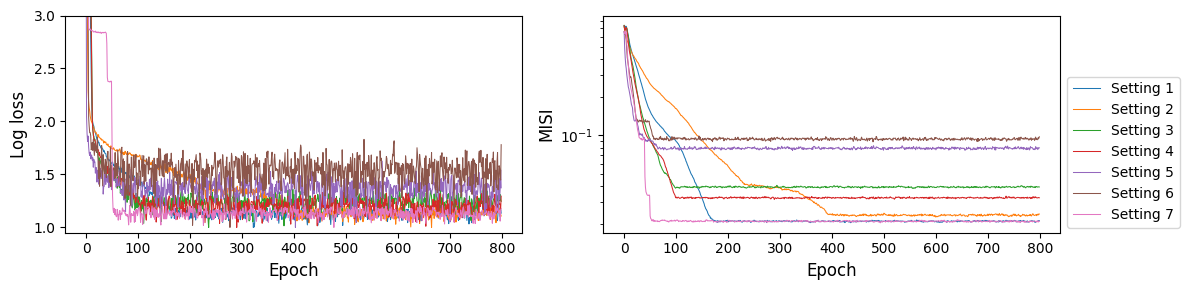

In [5]:
n_epoch = 800
loss_min = np.min(loss_all)
loss_max = np.max(loss_all)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

for i in range(7):
    # axes[0].plot(range(n_epoch)[10:], loss[i][10:], label=f"Setting {i+1}")
    axes[0].plot(range(n_epoch), np.log10(loss_all[i]-np.min(loss_all[i])+1)+1, label=f"Setting {i+1}", linewidth=0.75)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Log loss", fontsize=12)
axes[0].set_ylim(0.95, 3)

for i in range(7):
    axes[1].plot(range(n_epoch), isi_all[i], label=f"Setting {i+1}", linewidth=0.75)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("MISI", fontsize=12)
axes[1].set_yscale("log")
axes[1].legend(fontsize=10, bbox_to_anchor=(1, 0.75))

plt.tight_layout()
plt.savefig("/data/users4/xli/MISA/MISA-pytorch/runs/loss_isi.png", dpi=500)